In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Large_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Large_Trans.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Trans.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Patterns.txt
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Patterns.txt
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_accounts.csv
/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-la

Starting Preprocessing...
Training Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:20:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Performance ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1014634
           1       0.02      0.87      0.03      1035

    accuracy                           0.95   1015669
   macro avg       0.51      0.91      0.50   1015669
weighted avg       1.00      0.95      0.97   1015669

Average Precision (AUPRC): 0.3448


<Figure size 1000x600 with 0 Axes>

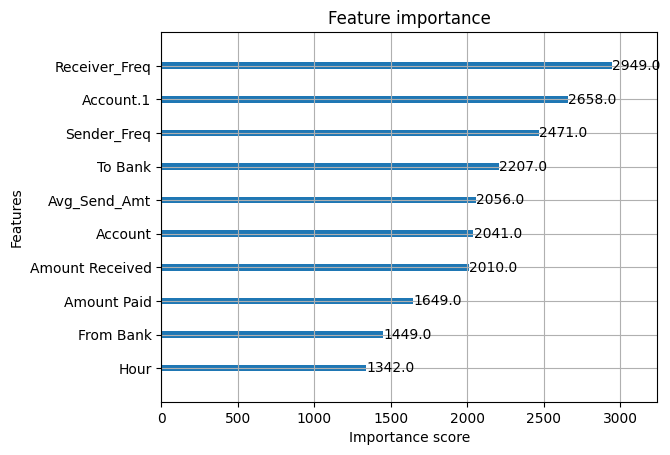

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Note: Using 'HI-Small_Trans.csv' for demonstration. 
# For 'Large' datasets, use dask or chunking.
df = pd.read_csv('/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv')

def preprocess_aml_data(df):
    print("Starting Preprocessing...")
    
    # 2. FEATURE ENGINEERING
    # Convert Timestamp to datetime and extract time-based features
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    
    # Create 'Amount Diff' - logic: laundering often involves split payments
    # Since Amount Received and Paid are often similar, the difference can be a signal
    df['Amt_Diff'] = df['Amount Received'] - df['Amount Paid']
    
    # Create 'Is_Cross_Currency' - laundering often crosses borders/currencies
    df['Cross_Currency'] = (df['Receiving Currency'] != df['Payment Currency']).astype(int)

    # 3. ACCOUNT BEHAVIOR FEATURES (Crucial for AML)
    # Frequency of transactions per account (sending and receiving)
    df['Sender_Freq'] = df.groupby('Account')['Amount Paid'].transform('count')
    df['Receiver_Freq'] = df.groupby('Account.1')['Amount Received'].transform('count')
    
    # Average transaction size per account
    df['Avg_Send_Amt'] = df.groupby('Account')['Amount Paid'].transform('mean')
    
    # 4. ENCODING CATEGORICAL VARIABLES
    # Handle Bank IDs and Payment Formats
    le = LabelEncoder()
    categorical_cols = ['Payment Format', 'Receiving Currency', 'Payment Currency']
    
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))
        
    # Account hashes are too high-cardinality for one-hot; 
    # Use Frequency Encoding or Label Encoding for Tree models
    df['Account'] = le.fit_transform(df['Account'].astype(str))
    df['Account.1'] = le.fit_transform(df['Account.1'].astype(str))
    
    # 5. DROP UNNECESSARY COLUMNS
    df = df.drop(['Timestamp'], axis=1)
    
    return df

df_cleaned = preprocess_aml_data(df)

# 6. TRAIN-TEST SPLIT
X = df_cleaned.drop('Is Laundering', axis=1)
y = df_cleaned['Is Laundering']

# Using stratify because the data is highly imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 7. MODELING (XGBOOST)
# scale_pos_weight is the most important parameter here.
# Formula: total_negative_examples / total_positive_examples
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio, # Handles the imbalance
    tree_method='hist',     # Faster training
    use_label_encoder=False,
    eval_metric='aucpr'     # Optimize for Area Under Precision-Recall Curve
)

print("Training Model...")
model.fit(X_train, y_train)

# 8. EVALUATION
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred))
print(f"Average Precision (AUPRC): {average_precision_score(y_test, y_prob):.4f}")

# 9. FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10)
plt.show()

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score

# 1. DATA LOADING
# Using 'HI-Small_Trans.csv' or the full 'HI-Large_Trans.csv'
df = pd.read_csv('/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv')

def engineering_pipeline(df):
    print("Engineering advanced features...")
    
    # Sort by time to ensure rolling windows make sense
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values(['Account', 'Timestamp'])
    
    # --- TEMPORAL FEATURES ---
    # Velocity: How many transactions in the last X records for this account?
    df['Tx_Velocity_Sender'] = df.groupby('Account')['Amount Paid'].transform(lambda x: x.rolling(window=5, min_periods=1).count())
    
    # Amount Volatility: Is the user suddenly sending much larger amounts than usual?
    df['Rolling_Avg_Sent'] = df.groupby('Account')['Amount Paid'].transform(lambda x: x.rolling(window=10, min_periods=1).mean())
    df['Amt_vs_Avg'] = df['Amount Paid'] / (df['Rolling_Avg_Sent'] + 1e-9)
    
    # --- CROSS-ENTITY FEATURES ---
    # Log transform amounts (monetary data is usually power-law distributed)
    df['Log_Amt_Paid'] = np.log1p(df['Amount Paid'])
    
    # Identify 'Smurfing' - many small transactions to the same receiver
    df['Small_Tx_Flag'] = (df['Amount Paid'] < df['Amount Paid'].median()).astype(int)
    
    # --- CATEGORICAL ENCODING ---
    # Using 'category' dtype for LightGBM's native handling
    cat_cols = ['Payment Format', 'Receiving Currency', 'Payment Currency', 'Account', 'Account.1']
    for col in cat_cols:
        df[col] = df[col].astype('category')
        
    return df

df_eng = engineering_pipeline(df)

# 2. TRAIN-TEST SPLIT (Time-based split is better for AML)
# We take the first 80% of time for training, last 20% for testing
df_eng = df_eng.sort_values('Timestamp')
split_idx = int(len(df_eng) * 0.8)

train_df = df_eng.iloc[:split_idx]
test_df = df_eng.iloc[split_idx:]

X_train = train_df.drop(['Is Laundering', 'Timestamp'], axis=1)
y_train = train_df['Is Laundering']
X_test = test_df.drop(['Is Laundering', 'Timestamp'], axis=1)
y_test = test_df['Is Laundering']

# 3. LIGHTGBM WITH FOCAL LOSS LOGIC
# LightGBM handles categorical features natively if they are 'category' type
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_cols)

params = {
    'objective': 'binary',
    'metric': 'auc_mu', # Good for imbalanced multi-class/binary
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'is_unbalance': True,  # Auto-adjusts weights for the 0.1% illicit cases
    'verbosity': -1
}

# 4. TRAINING
print("Training LightGBM model...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 5. EVALUATION
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

print("\n--- Advanced Metrics ---")
print(f"AUPRC (Precision-Recall): {average_precision_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

Engineering advanced features...


NameError: name 'cat_cols' is not defined

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score

# 1. MEMORY MANAGEMENT UTILITY
def reduce_mem_usage(df):
    """ Iterate through all columns and modify the data type to reduce memory usage. """
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and str(col_type) != 'category' and str(col_type) != 'datetime64[ns]':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

# 2. LOAD DATA
# Path for the IBM dataset on Kaggle
DATA_PATH = "/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv"
df = pd.read_csv(DATA_PATH)
df = reduce_mem_usage(df)

# 3. FEATURE ENGINEERING
def engineer_features(df):
    print("Engineering features...")
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values(['Account', 'Timestamp'])
    
    # Time Features
    df['Hour'] = df['Timestamp'].dt.hour.astype(np.int8)
    
    # Transaction Velocity (Count of recent transactions by same account)
    df['Trans_Count_7d'] = df.groupby('Account')['Amount Paid'].transform(lambda x: x.rolling(window=7, min_periods=1).count())
    
    # Financial Ratios
    df['Amt_Diff'] = (df['Amount Received'] - df['Amount Paid']).astype(np.float32)
    
    # Categorical Conversion
    cat_features = ['Payment Format', 'Receiving Currency', 'Payment Currency']
    for col in cat_features:
        df[col] = df[col].astype('category')
        
    return df.drop(['Timestamp', 'Account', 'Account.1'], axis=1)

df = engineer_features(df)
gc.collect() # Force garbage collection

# 4. TRAIN/TEST SPLIT
X = df.drop('Is Laundering', axis=1)
y = df['Is Laundering']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. LIGHTGBM MODEL
# is_unbalance=True is key for the 0.1% target rate
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'average_precision', # Standard for Kaggle AML/Fraud tasks
    'boosting_type': 'gbdt',
    'is_unbalance': True,
    'learning_rate': 0.03,
    'num_leaves': 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

print("Training high-performance model...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 6. EVALUATE
y_prob = model.predict(X_test)
print(f"\nFinal AUPRC: {average_precision_score(y_test, y_prob):.4f}")

Memory usage decreased to 314.80 MB (26.1% reduction)
Engineering features...
Training high-performance model...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	training's average_precision: 0.0223092	valid_1's average_precision: 0.0214062

Final AUPRC: 0.0214
